In [1]:
import time

import matplotlib.pyplot as plt

from motion_planning.obstacle_sets import BiasedPassage
from motion_planning.search import PRM
from motion_planning.space import ApproximationSpace, PointRobot

pygame 2.6.1 (SDL 2.28.4, Python 3.12.9)
Hello from the pygame community. https://www.pygame.org/contribute.html


# Setup Base Robot & Environment

In [2]:
base_env = PointRobot()
base_env.set_obstacles(BiasedPassage(num_walls=3))

# Setup Approximation Environment

In [4]:
approx_env = ApproximationSpace(
    space=base_env, batch_size=1000, do_overapproximation=True
)

# Create Task to Solve

In [5]:
start, target = base_env.sample_task()

# Initialize PRM with Base Environment

In [6]:
base_env_prm = PRM(base_env, num_samples=2000, num_neighbors=10, validate_edges=True)

# Create PRM Graph with Base Environment

In [7]:
start_time = time.time()
base_env_prm.create_graph()
end_time = time.time()

print(f"Time to create graph in seconds: {end_time - start_time}")

Connecting Edges Using knn strategy
Time to create graph in seconds: 14.32233715057373


# Initialize PRM with Approximation Environment

In [8]:
approx_env_prm = PRM(
    approx_env, num_samples=2000, num_neighbors=10, validate_edges=True
)

# Create PRM Graph with Approximation Environment

In [9]:
"""
Generating the graph using the approximation environment will be significantly faster due to
parallelized collision checking.
"""

start_time = time.time()
approx_env_prm.create_graph()
end_time = time.time()

print(f"Time to create graph in seconds: {end_time - start_time}")

Connecting Edges Using knn strategy
Time to create graph in seconds: 0.18991994857788086


# Visualize Base Environment and Approximation Environment PRM Graphs

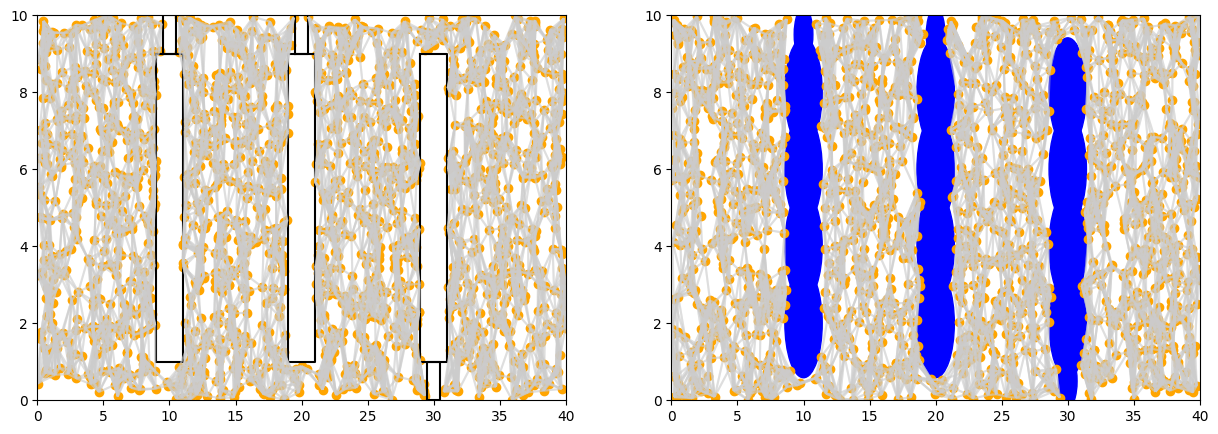

In [11]:
plt.rcParams["figure.figsize"] = [15, 5]
fig, ax = plt.subplots(1, 2)

base_env.draw_environment(ax[0])
base_env_prm.draw(ax[0])

approx_env.draw_environment(ax[1])
approx_env_prm.draw(ax[1])
plt.show()

# Search Graphs for Paths

In [12]:
base_env_prm_path = base_env_prm.search(start, target)
approx_env_prm_path = approx_env_prm.search(start, target)

# Visualize Base Environment and Approximation Environment PRM Graphs with Paths

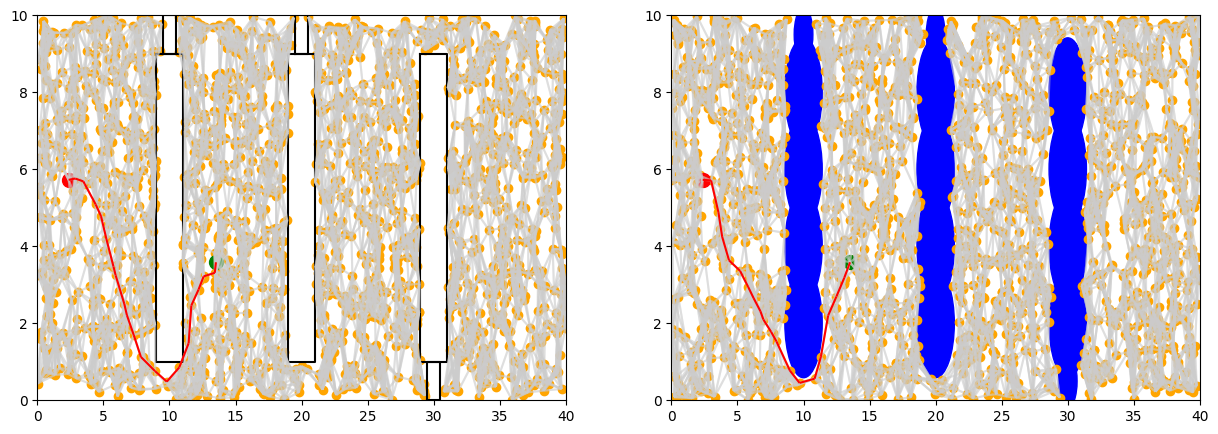

In [14]:
fig, ax = plt.subplots(1, 2)

base_env.draw_environment(ax[0])
base_env_prm.draw(ax[0], path=base_env_prm_path, show_task=True)

approx_env.draw_environment(ax[1])
approx_env_prm.draw(ax[1], path=approx_env_prm_path, show_task=True)
plt.show()